### Importar librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt

### Importar archivo CSV

In [7]:
telecom = pd.read_excel("Telecomunicaciones.xlsx")

### Exploración inicial

In [9]:
telecom.shape

(286, 17)

In [10]:
telecom.head(10)

,ID_dep,Departamento,Year,Uso_Cabina_porc,Tel_fija_und,Tel_movil_unid,Tel_public,Uso_inter_porc,Sub_internet_fijo_und,VAB_Tel_miles_2007base,PBI_regional_miles,Hogar_1_radio_porc,Hogar_1_tv_porc,Hogar_con_cable_porc,Hogar_1_compu_porc,Compus_por_muni_unid,ID_logit
0,1,Amazonas,2011,10.795442,5125.0,208272.0,1192.0,15.800000,1197.0,29703.0,2287107,81.341056,59.966255,13.559626,12.385407,643.0,0
1,1,Amazonas,2012,9.989996,4771.0,187753.0,1095.0,18.224461,1430.0,34466.0,2551601,79.400000,60.400000,22.911531,24.072226,3179.0,0
2,1,Amazonas,2013,9.444902,4225.0,208308.0,1031.0,16.793781,1363.0,38609.0,2682266,78.217649,61.029612,7.262254,11.541031,992.0,0
3,1,Amazonas,2014,8.969762,3606.0,230046.0,984.0,16.557231,1243.0,43519.0,2824603,73.377736,59.464673,22.456115,34.106994,2657.0,0
4,1,Amazonas,2015,8.598919,3289.0,248781.0,879.0,19.748475,1155.0,47927.0,2782128,71.126679,60.831013,5.302197,10.873073,1632.0,0
5,1,Amazonas,2016,6.772630,2604.0,264260.0,833.0,21.790462,938.0,54385.0,2784366,67.750905,58.709981,6.441040,15.597941,2510.0,0
6,1,Amazonas,2017,6.637417,2761.0,269583.0,797.0,25.497296,1619.0,60704.0,2940822,68.182585,58.662830,47.774417,32.997159,1377.0,0
7,1,Amazonas,2018,5.369275,2393.0,268558.0,682.0,26.099329,1885.0,63345.0,3118373,64.578420,60.213724,12.215548,20.400637,4502.0,0
8,1,Amazonas,2019,3.737897,2457.0,270047.0,202.0,33.645274,2259.0,68367.0,3168990,61.772658,61.803214,6.528793,8.325593,1411.0,0
9,1,Amazonas,2020,1.656297,2228.0,300495.0,172.0,45.145440,4424.0,74571.0,3034150,68.776722,64.251279,16.188294,14.379474,1019.0,0


In [11]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_dep                  286 non-null    int64  
 1   Departamento            286 non-null    object 
 2   Year                    286 non-null    int64  
 3   Uso_Cabina_porc         286 non-null    float64
 4   Tel_fija_und            264 non-null    float64
 5   Tel_movil_unid          264 non-null    float64
 6   Tel_public              264 non-null    float64
 7   Uso_inter_porc          286 non-null    float64
 8   Sub_internet_fijo_und   275 non-null    float64
 9   VAB_Tel_miles_2007base  264 non-null    float64
 10  PBI_regional_miles      286 non-null    int64  
 11  Hogar_1_radio_porc      286 non-null    float64
 12  Hogar_1_tv_porc         286 non-null    float64
 13  Hogar_con_cable_porc    286 non-null    float64
 14  Hogar_1_compu_porc      286 non-null    fl

Detectar columnas con valores no nulos menores a 286

In [13]:
columnas_incompletas = telecom.columns[telecom.count() < telecom.shape[0]]
print("Columnas que no llegaron a 286 valores:")
print(columnas_incompletas.tolist())

Columnas que no llegaron a 286 valores:
['Tel_fija_und', 'Tel_movil_unid', 'Tel_public', 'Sub_internet_fijo_und', 'VAB_Tel_miles_2007base']


### Tratamiento de duplicados

In [15]:
telecom.drop_duplicates()

,ID_dep,Departamento,Year,Uso_Cabina_porc,Tel_fija_und,Tel_movil_unid,Tel_public,Uso_inter_porc,Sub_internet_fijo_und,VAB_Tel_miles_2007base,PBI_regional_miles,Hogar_1_radio_porc,Hogar_1_tv_porc,Hogar_con_cable_porc,Hogar_1_compu_porc,Compus_por_muni_unid,ID_logit
0,1,Amazonas,2011,10.795442,5125.0,208272.0,1192.0,15.800000,1197.0,29703.0,2287107,81.341056,59.966255,13.559626,12.385407,643.0,0
1,1,Amazonas,2012,9.989996,4771.0,187753.0,1095.0,18.224461,1430.0,34466.0,2551601,79.400000,60.400000,22.911531,24.072226,3179.0,0
2,1,Amazonas,2013,9.444902,4225.0,208308.0,1031.0,16.793781,1363.0,38609.0,2682266,78.217649,61.029612,7.262254,11.541031,992.0,0
3,1,Amazonas,2014,8.969762,3606.0,230046.0,984.0,16.557231,1243.0,43519.0,2824603,73.377736,59.464673,22.456115,34.106994,2657.0,0
4,1,Amazonas,2015,8.598919,3289.0,248781.0,879.0,19.748475,1155.0,47927.0,2782128,71.126679,60.831013,5.302197,10.873073,1632.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,26,Ucayali,2017,10.310354,18507.0,379023.0,1690.0,41.780700,15206.0,201723.0,4305190,61.354987,76.166254,5.476167,21.942954,4081.0,0
282,26,Ucayali,2018,8.874589,16204.0,388511.0,1466.0,46.176802,16620.0,214407.0,4440780,62.424364,79.462887,55.388098,20.581914,2700.0,0
283,26,Ucayali,2019,7.749243,16115.0,418166.0,1132.0,49.721481,16726.0,229981.0,4625127,57.055145,76.593200,10.063391,44.435342,2492.0,0
284,26,Ucayali,2020,3.079345,15056.0,459911.0,1009.0,54.980128,21949.0,243940.0,4027781,67.059380,79.107944,49.955075,27.974003,775.0,0


Sin duplicados

### Tratamiento de valores nulos

Valores nulos: ['Tel_fija_und', 'Tel_movil_unid', 'Tel_public', 'Sub_internet_fijo_und', 'VAB_Tel_miles_2007base']

#### 1era Opción: Eliminar todos los valores nulos

In [20]:
# Eliminar filas que contienen al menos un valor nulo
df_sin_nulos = telecom.dropna()

# Eliminar columnas que contienen al menos un valor nulo
df_sin_nulos_columnas = telecom.dropna(axis=1)

In [21]:
df_sin_nulos.shape

(264, 17)

In [22]:
df_sin_nulos_columnas.shape

(286, 12)

#### 2da Opción: Reemplazar NaNs por la media

1. <u>En "Tel_fija_und"</u>

In [25]:
telecom["Tel_fija_und"]

0       5125.0
1       4771.0
2       4225.0
3       3606.0
4       3289.0
        ...   
281    18507.0
282    16204.0
283    16115.0
284    15056.0
285    17182.0
Name: Tel_fija_und, Length: 286, dtype: float64

In [26]:
round(telecom["Tel_fija_und"].mean())

116550

In [27]:
telecom["Tel_fija_und"] = telecom["Tel_fija_und"].fillna(round(telecom["Tel_fija_und"].mean()))

In [28]:
telecom["Tel_fija_und"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 286 entries, 0 to 285
Series name: Tel_fija_und
Non-Null Count  Dtype  
--------------  -----  
286 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB


In [29]:
pd.options.display.float_format = '{:,.0f}'.format  # Muestra sin notación científica y con separadores de miles. Para todos los casos
print(telecom["Tel_fija_und"].describe())

count         286
mean      116,550
std       344,168
min         2,228
25%        13,502
50%        30,618
75%        81,164
max     1,976,814
Name: Tel_fija_und, dtype: float64


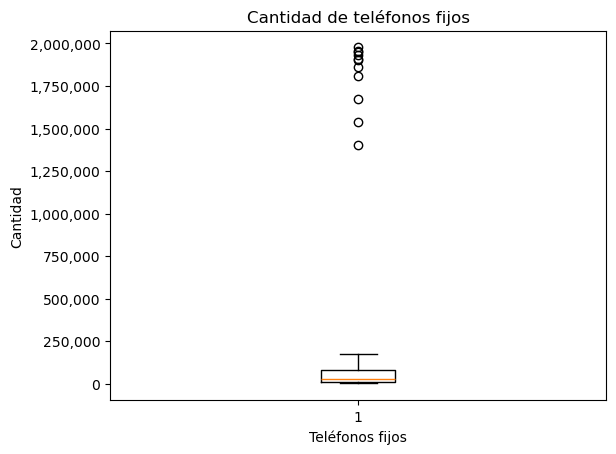

In [30]:
import matplotlib.ticker as ticker

# Crear el boxplot
plt.boxplot(telecom["Tel_fija_und"])

# Añadir etiquetas y título
plt.xlabel("Teléfonos fijos")
plt.ylabel("Cantidad")
plt.title("Cantidad de teléfonos fijos")

# Evitar notación científica en el eje Y
ax = plt.gca()  # Obtener el eje actual
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))  # Formato sin notación científica

# Mostrar el gráfico
plt.show()

Interpretación

- La mayoría de los datos están agrupados en valores bajos, cerca del 0 en comparación con los valores más altos.
- La mediana (línea dentro de la caja) está muy cerca del extremo inferior, lo que indica que más de la mitad de los datos tienen valores bajos. En otras palabras tiene **Distribución Asimétrica** (Sesgo a la derecha - Positivo)
    - En un boxplot simétrico, la mediana suele estar en el centro de la caja.
    - En tu gráfico, la mediana está más cerca del extremo inferior de la caja, lo que significa que más de la mitad de los datos tienen valores bajos.
    - Sin embargo, hay valores muy altos (outliers) que están mucho más alejados del resto, lo que hace que la media sea mayor que la mediana.
- Hay múltiples puntos fuera de la caja superior, lo que indica la presencia de valores atípicos muy elevados.
Estos outliers sugieren que algunas regiones tienen muchas más líneas de teléfono fijo en comparación con la mayoría.

Con una escala logarítmica, los valores pequeños y grandes se distribuyen mejor, lo que permite ver más detalles de los datos sin que los valores extremos dominen el gráfico.

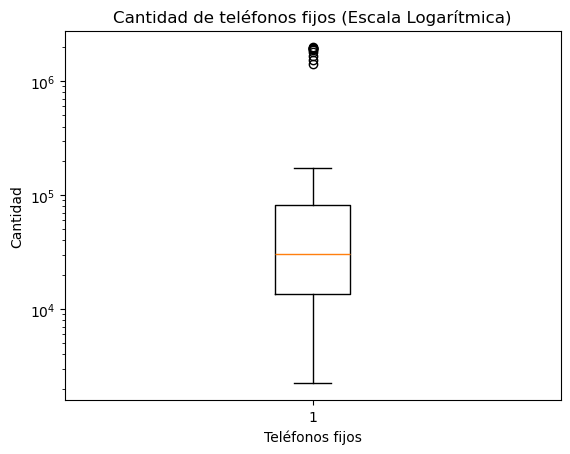

In [34]:
# Crear el boxplot
plt.boxplot(telecom["Tel_fija_und"])

# Añadir etiquetas y título
plt.xlabel("Teléfonos fijos")
plt.ylabel("Cantidad")
plt.title("Cantidad de teléfonos fijos (Escala Logarítmica)")

# Aplicar escala logarítmica al eje Y
plt.yscale("log")

# Mostrar el gráfico
plt.show()

La mayoría de los departamentos tienen entre 10,000 y 100,000 teléfonos fijos.

Aseguramos visualmente que tiene distribución asimétrica

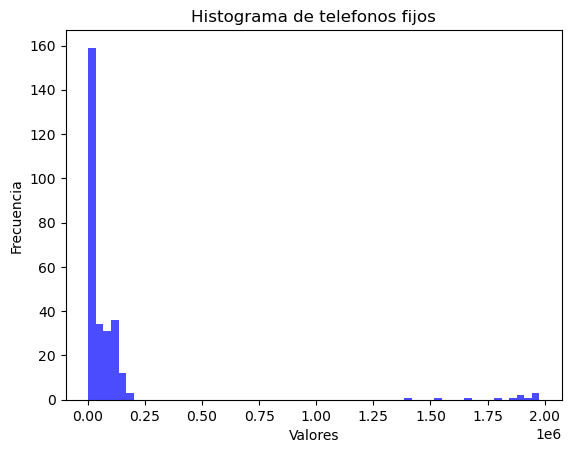

In [37]:
# Crear un histograma
plt.hist(telecom["Tel_fija_und"], bins = 60, color ="blue", alpha = 0.7)

# Añadir etiquetas y título
plt.xlabel("Valores")
plt.ylabel("Frecuencia")
plt.title("Histograma de telefonos fijos")

# Mostrar el histograma
plt.show()

2. <u>En "Tel_movil_unid"</u>

In [39]:
telecom["Tel_movil_unid"]

0     208,272
1     187,753
2     208,308
3     230,046
4     248,781
        ...  
281   379,023
282   388,511
283   418,166
284   459,911
285   502,497
Name: Tel_movil_unid, Length: 286, dtype: float64

In [40]:
round(telecom["Tel_movil_unid"].mean())

1176650

In [41]:
telecom["Tel_movil_unid"] = telecom["Tel_movil_unid"].fillna(round(telecom["Tel_movil_unid"].mean()))

In [42]:
telecom["Tel_movil_unid"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 286 entries, 0 to 285
Series name: Tel_movil_unid
Non-Null Count  Dtype  
--------------  -----  
286 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB


In [43]:
print(telecom["Tel_movil_unid"].describe())

count          286
mean     1,176,650
std      2,175,700
min        116,576
25%        307,856
50%        724,676
75%      1,176,650
max     14,922,707
Name: Tel_movil_unid, dtype: float64


Sucede un caso muy similar al anterior

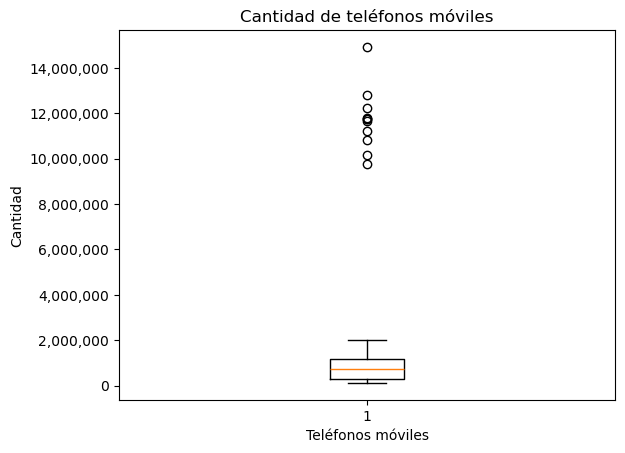

In [45]:
# Crear el boxplot
plt.boxplot(telecom["Tel_movil_unid"])

# Añadir etiquetas y título
plt.xlabel("Teléfonos móviles")
plt.ylabel("Cantidad")
plt.title("Cantidad de teléfonos móviles")

# Evitar notación científica en el eje Y
ax = plt.gca()  # Obtener el eje actual
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))  # Formato sin notación científica

# Mostrar el gráfico
plt.show()

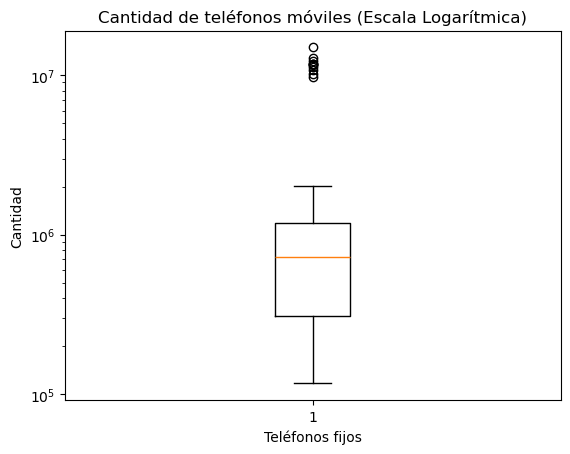

In [46]:
# Crear el boxplot
plt.boxplot(telecom["Tel_movil_unid"])

# Añadir etiquetas y título
plt.xlabel("Teléfonos fijos")
plt.ylabel("Cantidad")
plt.title("Cantidad de teléfonos móviles (Escala Logarítmica)")

# Aplicar escala logarítmica al eje Y
plt.yscale("log")

# Mostrar el gráfico
plt.show()

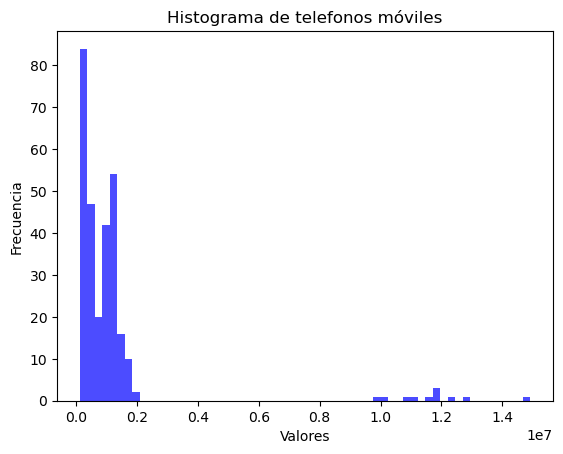

In [47]:
# Crear un histograma
plt.hist(telecom["Tel_movil_unid"], bins = 60, color ="blue", alpha = 0.7)

# Añadir etiquetas y título
plt.xlabel("Valores")
plt.ylabel("Frecuencia")
plt.title("Histograma de telefonos móviles")

# Mostrar el histograma
plt.show()

3. <u>En "Tel_public"</u>

In [49]:
telecom["Tel_public"]

0     1,192
1     1,095
2     1,031
3       984
4       879
       ... 
281   1,690
282   1,466
283   1,132
284   1,009
285   1,045
Name: Tel_public, Length: 286, dtype: float64

In [50]:
round(telecom["Tel_public"].mean())

6696

In [51]:
telecom["Tel_public"] = telecom["Tel_public"].fillna(round(telecom["Tel_public"].mean()))

In [52]:
telecom["Tel_public"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 286 entries, 0 to 285
Series name: Tel_public
Non-Null Count  Dtype  
--------------  -----  
286 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB


In [53]:
print(telecom["Tel_public"].describe())

count       286
mean      6,696
std      15,130
min         130
25%       1,133
50%       3,051
75%       6,696
max     104,841
Name: Tel_public, dtype: float64


Caso muy similar al anterior

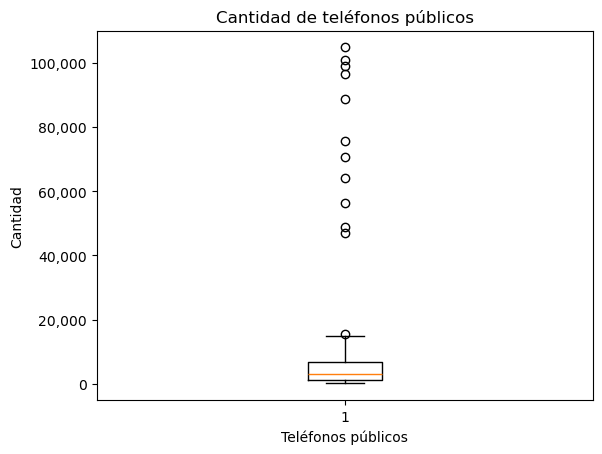

In [55]:
# Crear el boxplot
plt.boxplot(telecom["Tel_public"])

# Añadir etiquetas y título
plt.xlabel("Teléfonos públicos")
plt.ylabel("Cantidad")
plt.title("Cantidad de teléfonos públicos")

# Evitar notación científica en el eje Y
ax = plt.gca()  # Obtener el eje actual
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))  # Formato sin notación científica

# Mostrar el gráfico
plt.show()

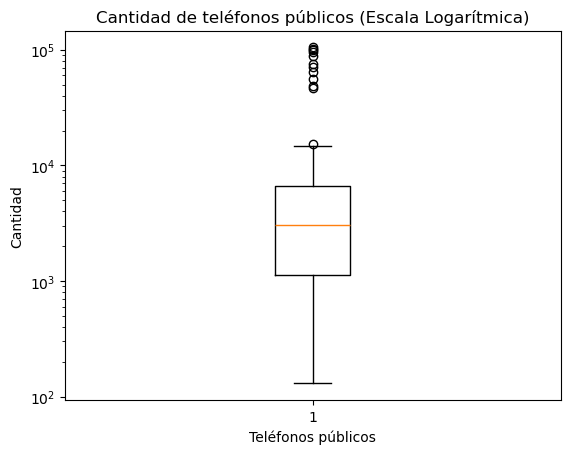

In [56]:
# Crear el boxplot
plt.boxplot(telecom["Tel_public"])

# Añadir etiquetas y título
plt.xlabel("Teléfonos públicos")
plt.ylabel("Cantidad")
plt.title("Cantidad de teléfonos públicos (Escala Logarítmica)")

# Aplicar escala logarítmica al eje Y
plt.yscale("log")

# Mostrar el gráfico
plt.show()

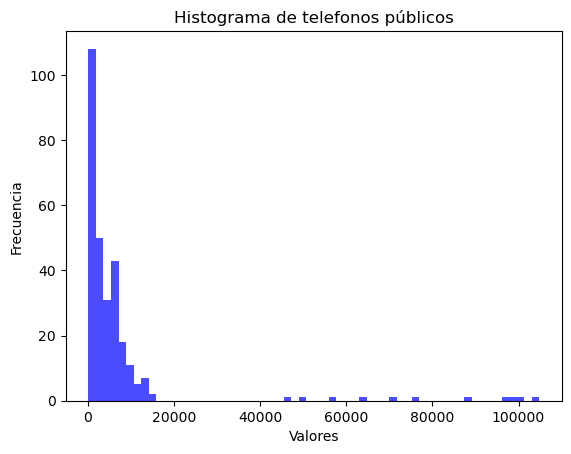

In [57]:
# Crear un histograma
plt.hist(telecom["Tel_public"], bins = 60, color ="blue", alpha = 0.7)

# Añadir etiquetas y título
plt.xlabel("Valores")
plt.ylabel("Frecuencia")
plt.title("Histograma de telefonos públicos")

# Mostrar el histograma
plt.show()

4. <u>En "Sub_internet_fijo_und"</u>

In [59]:
telecom["Sub_internet_fijo_und"]

0      1,197
1      1,430
2      1,363
3      1,243
4      1,155
       ...  
281   15,206
282   16,620
283   16,726
284   21,949
285   26,399
Name: Sub_internet_fijo_und, Length: 286, dtype: float64

In [60]:
round(telecom["Sub_internet_fijo_und"].mean())

84386

In [61]:
telecom["Sub_internet_fijo_und"] = telecom["Sub_internet_fijo_und"].fillna(round(telecom["Sub_internet_fijo_und"].mean()))

In [62]:
telecom["Sub_internet_fijo_und"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 286 entries, 0 to 285
Series name: Sub_internet_fijo_und
Non-Null Count  Dtype  
--------------  -----  
286 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB


In [63]:
print(telecom["Sub_internet_fijo_und"].describe())

count         286
mean       84,386
std       238,524
min           141
25%         9,612
50%        26,108
75%        68,542
max     1,669,955
Name: Sub_internet_fijo_und, dtype: float64


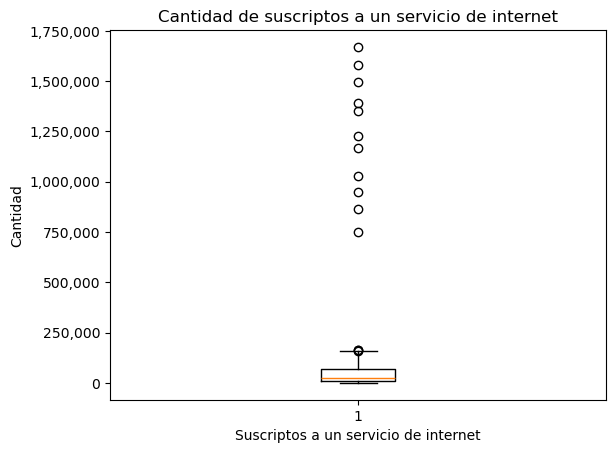

In [64]:
# Crear el boxplot
plt.boxplot(telecom["Sub_internet_fijo_und"])

# Añadir etiquetas y título
plt.xlabel("Suscriptos a un servicio de internet")
plt.ylabel("Cantidad")
plt.title("Cantidad de suscriptos a un servicio de internet")

# Evitar notación científica en el eje Y
ax = plt.gca()  # Obtener el eje actual
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))  # Formato sin notación científica

# Mostrar el gráfico
plt.show()

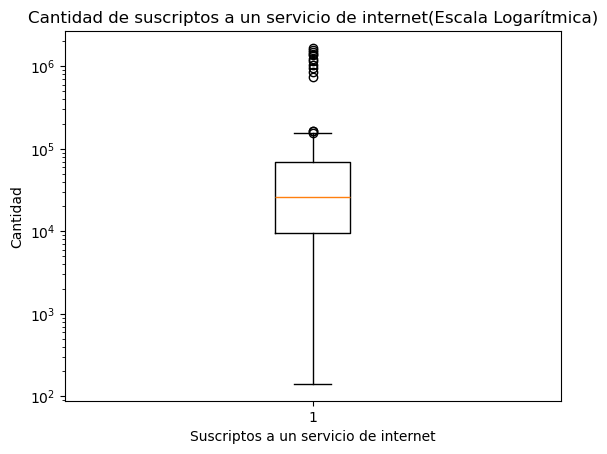

In [65]:
# Crear el boxplot
plt.boxplot(telecom["Sub_internet_fijo_und"])

# Añadir etiquetas y título
plt.xlabel("Suscriptos a un servicio de internet")
plt.ylabel("Cantidad")
plt.title("Cantidad de suscriptos a un servicio de internet(Escala Logarítmica)")

# Aplicar escala logarítmica al eje Y
plt.yscale("log")

# Mostrar el gráfico
plt.show()

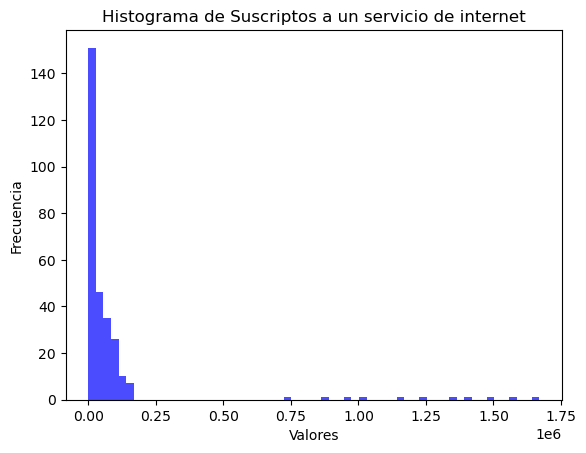

In [66]:
# Crear un histograma
plt.hist(telecom["Sub_internet_fijo_und"], bins = 60, color ="blue", alpha = 0.7)

# Añadir etiquetas y título
plt.xlabel("Valores")
plt.ylabel("Frecuencia")
plt.title("Histograma de Suscriptos a un servicio de internet")

# Mostrar el histograma
plt.show()

5. <u>En "VAB_Tel_miles_2007base"</u>

In [68]:
telecom["VAB_Tel_miles_2007base"]

0      29,703
1      34,466
2      38,609
3      43,519
4      47,927
        ...  
281   201,723
282   214,407
283   229,981
284   243,940
285   275,306
Name: VAB_Tel_miles_2007base, Length: 286, dtype: float64

In [69]:
round(telecom["VAB_Tel_miles_2007base"].mean())

867485

In [70]:
telecom["VAB_Tel_miles_2007base"] = telecom["VAB_Tel_miles_2007base"].fillna(round(telecom["VAB_Tel_miles_2007base"].mean()))

In [71]:
telecom["VAB_Tel_miles_2007base"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 286 entries, 0 to 285
Series name: VAB_Tel_miles_2007base
Non-Null Count  Dtype  
--------------  -----  
286 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB


In [72]:
print(telecom["VAB_Tel_miles_2007base"].describe())

count          286
mean       867,485
std      2,562,748
min         16,496
25%        111,124
50%        280,356
75%        623,212
max     18,041,212
Name: VAB_Tel_miles_2007base, dtype: float64


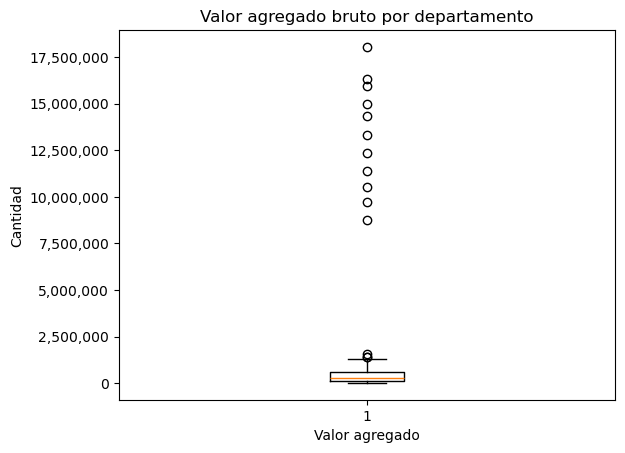

In [124]:
# Crear el boxplot
plt.boxplot(telecom["VAB_Tel_miles_2007base"])

# Añadir etiquetas y título
plt.xlabel("Valor agregado")
plt.ylabel("Cantidad")
plt.title("Valor agregado bruto por departamento")

# Evitar notación científica en el eje Y
ax = plt.gca()  # Obtener el eje actual
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))  # Formato sin notación científica

# Mostrar el gráfico
plt.show()

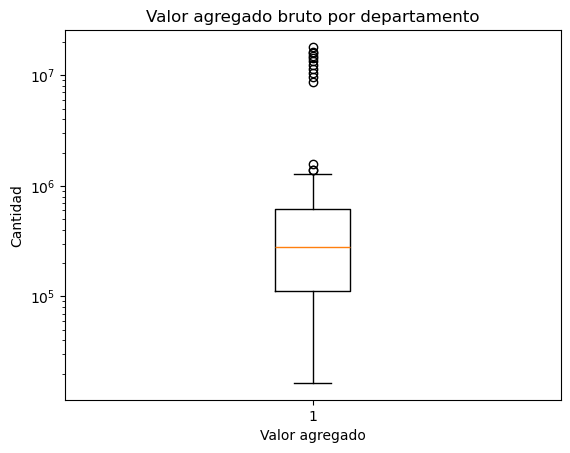

In [126]:
# Crear el boxplot
plt.boxplot(telecom["VAB_Tel_miles_2007base"])

# Añadir etiquetas y título
plt.xlabel("Valor agregado")
plt.ylabel("Cantidad")
plt.title("Valor agregado bruto por departamento")

# Aplicar escala logarítmica al eje Y
plt.yscale("log")

# Mostrar el gráfico
plt.show()

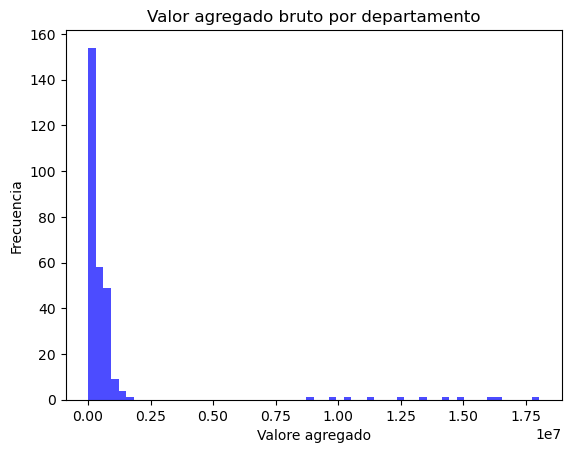

In [128]:
# Crear un histograma
plt.hist(telecom["VAB_Tel_miles_2007base"], bins = 60, color ="blue", alpha = 0.7)

# Añadir etiquetas y título
plt.xlabel("Valore agregado")
plt.ylabel("Frecuencia")
plt.title("Valor agregado bruto por departamento")

# Mostrar el histograma
plt.show()

Conclusión general

Claramente hay departamentos que superan la cantidad de servicios telefónicos